# Analýza a predikce cen ojetých vozů
* Cílem projektu je vypořádat se s regresní úlohou, včetně kompletního očištění dat, extrakce příznaků a optimalizace hyperparametrů několika regresních modelů.


## Zdroj dat

Budeme se zabývat predikcí ceny prodávaných automobilů.
K dispozici máme trénovací data v souboru `data.csv` a data na vyhodnocení v souboru `evaluation.csv`.

#### Seznam příznaků:

* ID - identifikátor záznamu
* Make - výrobce vozidla
* Model - název modelu vozidla
* Price - prodejní cena; **cílová proměnná, kterou predikujeme**
* Year - rok výroby
* Kilometer - počet najetých kilometrů
* Fuel Type - typ paliva
* Transmission - typ převodovky
* Location - město, kde k prodeji došlo
* Color - barva vozidla
* Owner - počet předchozích majitelů
* Seller Type - typ prodávajícího subjektu (osoba, firma)
* Engine - objem motoru v kubických centimetrech
* Max Power - maximální výkon motoru
* Max Torque - maximální kroutící moment motoru
* Drivetrain - typ poháněných náprav (FWD - pohon přední nápravy, RWD - pohon zadní nápravy, AWD - pohon všech náprav)
* Length - délka vozidla v mm
* Width - šířka vozidla v mm
* Height - výška vozidla v mm
* Seating Capacity - maximální počet míst k sezení
* Fuel Tank Capacity - kapacita nádrže v litrech


## Jak budeme postupovat
  * Načteme data ze souboru `data.csv`, rozdělíme je na podmnožiny pro trénování (trénovací), porovnávání modelů (validační) a následnou predikci výkonnosti finálního modelu (testovací).
  * Provedeme základní předzpracování dat:
    * Projdeme si jednotlivé příznaky a transformujeme je do vhodné podoby pro použití
    * Vypořádáme se s chybějícími hodnotami.
  * Na připravená data postupně aplikujeme 3 regresní modely: **rozhodovací strom**, **metoda nejbližších sousedů** a **lineární regrese**:
    * Budeme experimentovat s normalizací, pokud pro daný model očekáváme její příznivý vliv.
    * Vybereme si hlavní hyperparametry k ladění a najdeme jejich nejlepší hodnoty (vzhledem k MSE).
    * Pro model s nejlepšími hodnotami hyperparametrů na validační množině určíme jeho chybu pomocí MSE.
  * Ze všech zkoušených možností v předchozím kroku vybereme finální model a odhadneme, jakou chybu měřenou pomocí RMSE můžeme očekávat na nových datech, která jsme doposud neměli k dispozici.
    
  * Nakonec model použijeme pro predikci cen aut ze souboru `evaluation.csv`.
  * Cílem je minimalizovat RMSE na neznámých datech.


# Vypracování

## Předzpracování dat

In [111]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from pandas.api.types import CategoricalDtype
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import ParameterGrid
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler, MaxAbsScaler

In [112]:
df = pd.read_csv("data.csv")
display(df.info())
display(df.describe())
display(df.head())
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1683 entries, 0 to 1682
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  1683 non-null   int64  
 1   Make                1683 non-null   object 
 2   Model               1683 non-null   object 
 3   Price               1683 non-null   int64  
 4   Year                1683 non-null   int64  
 5   Kilometer           1683 non-null   int64  
 6   Fuel Type           1683 non-null   object 
 7   Transmission        1683 non-null   object 
 8   Location            1683 non-null   object 
 9   Color               1683 non-null   object 
 10  Owner               1683 non-null   object 
 11  Seller Type         1683 non-null   object 
 12  Engine              1667 non-null   object 
 13  Max Power           1667 non-null   object 
 14  Max Torque          1667 non-null   object 
 15  Drivetrain          1618 non-null   object 
 16  Length

None

,ID,Price,Year,Kilometer,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
count,1683.000000,1.683000e+03,1683.000000,1.683000e+03,1683.000000,1683.000000,1683.000000,1683.000000,1641.000000
mean,1005.180630,1.570817e+06,2016.569816,5.402617e+04,4276.891266,1767.269162,1592.308378,5.307190,51.919805
std,576.607661,1.790412e+06,3.255157,6.084482e+04,438.106943,134.130438,135.277833,0.814619,15.028163
min,0.000000,4.900000e+04,1988.000000,0.000000e+00,3099.000000,1475.000000,1281.000000,2.000000,15.000000
25%,502.500000,4.950000e+05,2014.000000,2.800000e+04,3985.000000,1695.000000,1485.000000,5.000000,42.000000
50%,1010.000000,8.250000e+05,2017.000000,4.985700e+04,4360.000000,1775.000000,1545.000000,5.000000,48.000000
75%,1502.000000,1.870000e+06,2019.000000,7.200000e+04,4620.000000,1831.000000,1678.000000,5.000000,60.000000
max,1994.000000,1.290000e+07,2022.000000,2.000000e+06,5453.000000,2220.000000,1995.000000,8.000000,104.000000


,ID,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,...,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,1036,BMW,X1 sDrive20d,3250000,2020,32005,Diesel,Automatic,Bangalore,Blue,...,Individual,1995 cc,184 bhp @ 4000 rpm,380 Nm @ 1750 rpm,RWD,4454.0,1798.0,1545.0,5.0,61.0
1,754,Land Rover,Evoque SE Dynamic,6500000,2021,12000,Diesel,Automatic,Hyderabad,White,...,Individual,1999 cc,177 bhp @ 4000 rpm,430 Nm @ 1750 rpm,AWD,4360.0,2120.0,1635.0,5.0,57.0
2,840,Maruti Suzuki,S-Cross Zeta 1.6,800000,2017,52836,Diesel,Manual,Ahmedabad,Blue,...,Individual,1598 cc,118 bhp @ 3750 rpm,320 Nm @ 1750 rpm,FWD,4300.0,1765.0,1590.0,5.0,48.0
3,1127,Land Rover,Evoque HSE,3800000,2017,50000,Diesel,Automatic,Mumbai,White,...,Individual,1999 cc,177 bhp @ 4000 rpm,430 Nm @ 1750 rpm,AWD,4360.0,2120.0,1635.0,5.0,57.0
4,271,BMW,3-Series 320d Luxury Line,2950000,2018,75000,Diesel,Automatic,Coimbatore,White,...,Individual,1995 cc,188 bhp @ 4000 rpm,400 Nm @ 1750 rpm,RWD,4633.0,1811.0,1429.0,5.0,57.0


(1683, 21)

Dataset má 21 příznaků a 1683 datových bodů. U některých příznaků jako *Engine*, *Max Power*, *Max Torque* a *Drivetrain* máme několik chybějících hodnot. Ty můžeme nahradit mediánem u numerických příznaků či modem u kategorických příznaků.
Příznaky ve správném číselném typu:
- *Price*, *Year*, *Kilometer*, *Length*, *Width*, *Height*, *Seating Capacity* a *Fuel Tank Capacity*

Ostatní jsou typu object, s čímž se budeme muset vypořádat.
Nyní si ukažme, kolik unikátních hodnot mají jednotlivé příznaky.

In [113]:
def printUniqueObjectValues(df):
    for col in df.columns:
        if df[col].dtype == "object":
            print(f"Feature: {col} has {df[col].nunique()} unique values")
            print("\t", df[col].unique()[:8])
            print("\n")

printUniqueObjectValues(df)

Feature: Make has 30 unique values
	 ['BMW' 'Land Rover' 'Maruti Suzuki' 'Honda' 'Mercedes-Benz' 'Hyundai'
 'Tata' 'MG']


Feature: Model has 919 unique values
	 ['X1 sDrive20d' 'Evoque SE Dynamic' 'S-Cross Zeta 1.6' 'Evoque HSE'
 '3-Series 320d Luxury Line' 'Ciaz VDi SHVS' 'Ertiga VDi' 'City 1.5 V AT']


Feature: Fuel Type has 8 unique values
	 ['Diesel' 'Petrol' 'Petrol + CNG' 'CNG' 'Electric' 'CNG + CNG' 'Hybrid'
 'LPG']


Feature: Transmission has 2 unique values
	 ['Automatic' 'Manual']


Feature: Location has 76 unique values
	 ['Bangalore' 'Hyderabad' 'Ahmedabad' 'Mumbai' 'Coimbatore' 'Lucknow'
 'Agra' 'Gurgaon']


Feature: Color has 16 unique values
	 ['Blue' 'White' 'Silver' 'Grey' 'Red' 'Black' 'Maroon' 'Brown']


Feature: Owner has 6 unique values
	 ['Second' 'First' 'Third' 'UnRegistered Car' 'Fourth' '4 or More']


Feature: Seller Type has 3 unique values
	 ['Individual' 'Corporate' 'Commercial Registration']


Feature: Engine has 101 unique values
	 ['1995 cc' '1999 cc' '

Kategorické nominální příznaky:
- *Make*, *Transmission*, *Location*, *Color*, *Seller type*, *Drivetrain*, *Model*\
- Na *Model* si musíme dát pozor. Ze všech 1600 datových bodů obsahuje 900 různých hodnot. Jeho datový přínos je mizivý a nebudeme ho nadále uvažovat.
- *Fuel Type* obsahuje hodnoty *CNG + CNG*. Těžko soudit, jestli se to liší od *CNG*, ale pro jednoduchost tyto hodnoty sjednotíme.
- Tyto příznaky budeme později kodovat pomocí One-Hot.

Kategorické ordinální příznaky:
- *Owner* uvádí počet předchozích majitelů

Spojité příznaky:
- *Engine*. Ten musíme řádně vyextrahovat a udělat z něj číselný příznak.
- *Max Power* a *Max Torque*. Tyto příznaky obsahují dvojici hodnot - svojí hodnotu a při jakých otáčkách motoru tomu tak je. Abychom neměli zbytečně moc příznaků, informaci o počtu otáček, která je dle mého názoru zbytečná, zanedbáme. Výkon a točivý moment jsou ale sami o sobě velmi důležité.

In [114]:
df["Fuel Type"] = df["Fuel Type"].str.replace("CNG + CNG", "CNG")

# převedení kategorických příznaků na category
for col in ["Make", "Transmission", "Location", "Color", "Seller Type", "Drivetrain", "Fuel Type"]:
    df[col] = df[col].astype("category")

# vynechání příznaku Make a Id
df.drop("Model", axis=1, inplace=True)
df.drop("ID", axis=1, inplace=True)

# převedení příznaku Owner na ordinální kategorický
owner_cat_types = ["UnRegistered Car", "First", "Second", "Third", "Fourth", "4 or More"]
df["Owner"] = df["Owner"].astype(CategoricalDtype(categories=owner_cat_types, ordered=True))

In [115]:
df["Engine"] = df["Engine"].str.replace("cc", "")
df["Engine"] = df["Engine"].astype("float64")

In [116]:
def extractNumber(p):
    if pd.isnull(p):
        return None
    res = re.search(r"[0-9]+(\.[0-9]+)?", str(p))
    return float(res.group())

# Vytěžení výkonu a točivého momentu
df["Max Power"] = df["Max Power"].apply(extractNumber)
df["Max Power"] = df["Max Power"].astype("float64")

df["Max Torque"] = df["Max Torque"].apply(extractNumber)
df["Max Torque"] = df["Max Torque"].astype("float64")

Nyní máme všechny příznaky předzpracované. Je tedy čas na doplnění null hodnot, to ale musíme udělat až po rozdělení dat na trénovací, validační a testovací, aby medián či modus nebyl kalkulován (mj.) z testovacích dat. Vydáme se klasickou cestou 60 x 20 x 20 procent.

## Příprava třídy DataWrapper obalující DataFrame

Kvůli časté manipulaci s DataFramem si pro jednodušší práci a pro větší bezpečnost vytvoříme třídu DataWrapper. Ta přijímá dataframe, který si pro sebe zkopíruje. Jakoukoliv manipulaci s dataframem tedy budeme provádět izolovaně v instanci této třídy. Třída implementuje:
- split_data()
- fill_missing()
- one_hot_encode()
- preprocess()
- scale()

Z vnějšku do funkce Datawrapper budeme vždy přistupovat k _ohe instancím. Proto platí, že kdykoliv zavoláme funkci one_hot_encode, budeme mít jistotu, že data nemáme ovlivněna předchozí manipulací v jiném modelu či škálováním dříve.

In [117]:
random_seed = 42

class DataWrapper:

    def __init__(self, df):
        self.df = df.copy()

        self.x_train = None
        self.x_val = None
        self.x_test = None

        self.y_train = None
        self.y_val = None
        self.y_test = None

        self.x_train_ohe = None
        self.x_val_ohe = None
        self.x_test_ohe = None

        self.encoder = None

        self.preprocess()

    def split_data(self):
        Y = self.df["Price"]
        X = self.df.drop("Price", axis=1)
        self.x_train, self.x_val, self.y_train, self.y_val = train_test_split(X, Y, train_size=0.6, random_state=random_seed)
        self.x_val, self.x_test, self.y_val, self.y_test = train_test_split(self.x_val, self.y_val, train_size=0.5, random_state=random_seed)

    # Vždy dopnujeme medianem, nebo modem.
    def fill_missing(self):
        for col in self.df.drop("Price", axis=1).columns:
            if self.x_train[col].dtype == "category":
                missing_value = self.x_train[col].mode()[0]
            elif self.x_train[col].dtype == "int64" or self.x_train[col].dtype == "float64" or self.x_train[col].dtype == "int8":
                missing_value = self.x_train[col].median()
            for data in [self.x_train, self.x_val, self.x_test]:
                data[col] = data[col].fillna(missing_value)

    def one_hot_encode(self):
        category_cols = self.x_train.select_dtypes(include=["category"]).columns.tolist()
        numeric_cols = self.x_train.select_dtypes(include=["int64", "float64", "int8"]).columns.tolist()

        self.encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

        train_cat = self.encoder.fit_transform(self.x_train[category_cols])
        val_cat = self.encoder.transform(self.x_val[category_cols])
        test_cat = self.encoder.transform(self.x_test[category_cols])

        dummy_category_cols = self.encoder.get_feature_names_out(category_cols)

        train_cat_df = pd.DataFrame(train_cat, columns=dummy_category_cols, index=self.x_train.index)
        val_cat_df = pd.DataFrame(val_cat, columns=dummy_category_cols, index=self.x_val.index)
        test_cat_df = pd.DataFrame(test_cat, columns=dummy_category_cols, index=self.x_test.index)

        self.x_train_ohe = pd.concat([train_cat_df, self.x_train[numeric_cols]], axis=1)
        self.x_val_ohe = pd.concat([val_cat_df, self.x_val[numeric_cols]], axis=1)
        self.x_test_ohe = pd.concat([test_cat_df, self.x_test[numeric_cols]], axis=1)

    def scale(self, scaler):
        # pro všechny případy očistíme _ohe dataframy od předchozích úprav
        self.one_hot_encode()
        if scaler is None:
            return
        numeric_cols = self.x_train.select_dtypes(include=["int64", "float64", "int8"]).columns.tolist()
        scaler.fit(self.x_train_ohe[numeric_cols])
        self.x_train_ohe[numeric_cols] = scaler.transform(self.x_train_ohe[numeric_cols])
        self.x_val_ohe[numeric_cols] = scaler.transform(self.x_val_ohe[numeric_cols])
        self.x_test_ohe[numeric_cols] = scaler.transform(self.x_test_ohe[numeric_cols])

    def preprocess(self):
        self.split_data()
        self.fill_missing()



In [118]:
dw = DataWrapper(df)
dw.one_hot_encode()

## Lineární regrese
Lineární regrese je vhodná. Je méně náchylná k přeučení než zbylé dvě metody, ale má problém s daty s korelovanými příznaky.

### Prvotní spuštění
Nejprve spustíme lineární regresi bez jakýchkoliv úprav, abychom měli představu o počátečním RMSE

In [119]:
clf = LinearRegression()
clf.fit(dw.x_train_ohe, dw.y_train)
Yval_predict = clf.predict(dw.x_val_ohe)

rmse = root_mean_squared_error(dw.y_val, Yval_predict)
print(rmse)

926683.2610107878


Lineární regrese nám dává RMSE přes 926 000, což je špatný výsledek. Je něco, co můžeme upravit, abychom model zlepšili?

V tento moment máme uložený příznak *owner* jako categoricalDType. Jak k němu přistupuje OneHotEncoder? My pomocí OneHotEncoderu kódujeme všechny příznaky, které mu dáme, včetně numerických. Proto mu dáváme pouze kategorické příznaky, což je i příznak *owner*. Nebylo by lepší, přistupovat k tomuto příznaku jako k numerickému? Těžko říct, jestli je cena lineární v závislosti na majiteli, ale určitě snížíme počet příznaků.
Škálovat data u lineární regrese nemá smysl, výsledky by byly stejné.

### Výběr scaleru a porovnání *Owner* jako kategorie a jako číslo

In [120]:
dw_owner_numeric = DataWrapper(df)
dw_owner_numeric.df["Owner"] = dw_owner_numeric.df["Owner"].cat.codes
dw_owner_numeric.preprocess()
dw_owner_numeric.one_hot_encode()

clf.fit(dw.x_train_ohe, dw.y_train)
yval_predict = clf.predict(dw.x_val_ohe)
rmse = root_mean_squared_error(dw.y_val, yval_predict)
print(f"RMSE with owner as category: {rmse}")

clf.fit(dw_owner_numeric.x_train_ohe, dw_owner_numeric.y_train)
yval_predict = clf.predict(dw_owner_numeric.x_val_ohe)
rmse = root_mean_squared_error(dw_owner_numeric.y_val, yval_predict)
print(f"RMSE with owner as int: {rmse}",end="\n\n")

RMSE with owner as category: 926683.2610107878
RMSE with owner as int: 928204.3347212109



Rozdíl přístupu k příznaku *Owner* mělo opravdu malou roli, rozdíl je zanedbatelný

## Regresní rozhodovací strom
Nevýhodou rozhodovacího stromu je jeho nestabilita. Malé vychýlení dat znamená, že naučený strom bude vypadat úplně jinak.

### Prvotní spuštění

In [121]:
clf = DecisionTreeRegressor(random_state=random_seed)
clf.fit(dw.x_train_ohe, dw.y_train)
yval_predict = clf.predict(dw.x_val_ohe)
rmse = root_mean_squared_error(dw.y_val, yval_predict)
print("RMSE:", rmse)

RMSE: 649868.6921332213


### Ladění maximální hloubky stromu
Vidíme, že RMSE bez jakýchkoliv úprav je 650k. Zkusme opět rozdílné přístupy pro *owner*.
Navíc můžeme ladit hyperparametr maximální hloubky:

Best depth for categorical: 9
Best RMSE for categorical: 641402.0496848677

Best depth for numerical: 20
Best RMSE for numerical: 633929.5859891616


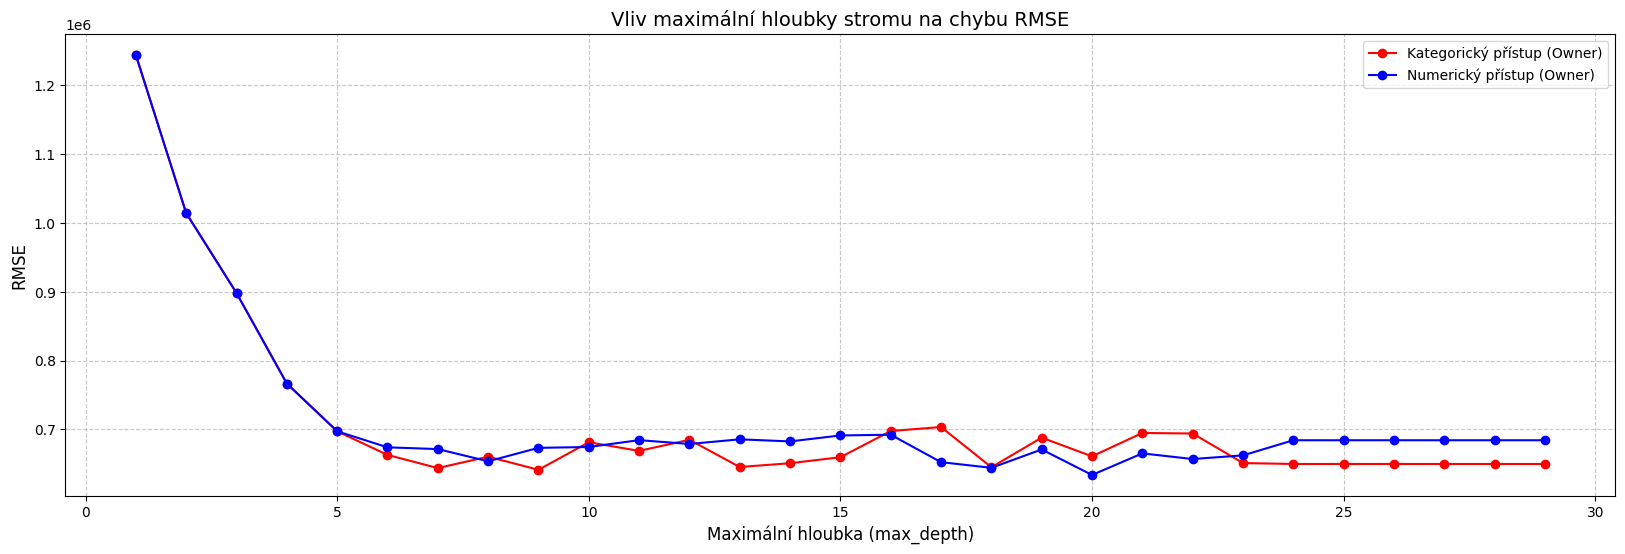

In [122]:
depths = range(1, 30)

rmse_category = []
rmse_numerical = []
for depth in depths:
    clf = DecisionTreeRegressor(random_state=random_seed, max_depth=depth)

    clf.fit(dw.x_train_ohe, dw.y_train)
    yval_predict = clf.predict(dw.x_val_ohe)
    rmse = root_mean_squared_error(dw.y_val, yval_predict)
    rmse_category.append(rmse)

    clf.fit(dw_owner_numeric.x_train_ohe, dw_owner_numeric.y_train)
    yval_predict = clf.predict(dw_owner_numeric.x_val_ohe)
    rmse = root_mean_squared_error(dw_owner_numeric.y_val, yval_predict)
    rmse_numerical.append(rmse)

fig, ax = plt.subplots(figsize=(20, 6))
ax.plot(depths, rmse_category, 'or-', label='Kategorický přístup (Owner)')
ax.plot(depths, rmse_numerical, 'ob-', label='Numerický přístup (Owner)')

ax.set_title("Vliv maximální hloubky stromu na chybu RMSE", fontsize=14)
ax.set_xlabel("Maximální hloubka (max_depth)", fontsize=12)
ax.set_ylabel("RMSE", fontsize=12)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.7)

print("Best depth for categorical:", depths[np.argmin(rmse_category)])
print("Best RMSE for categorical:", rmse_category[np.argmin(rmse_category)])
print("")
print("Best depth for numerical:", depths[np.argmin(rmse_numerical)])
print("Best RMSE for numerical:", rmse_numerical[np.argmin(rmse_numerical)])

Nejlepšího výsledku jsme dosáhli s hloubkou 20. Nicméně, strom má i jiné hyperparametry. Kromě hloubky můžeme zkoušet různá kritéria pro měření přesnosti, různá velikost minimálního počtu datových bodů pro každý list, či různá velikost minimálního počtu rozdělení.

### Ladění ostatních hyperparametrů

In [123]:
param_grid = {
    "max_depth": range(1, 25),
    "min_samples_leaf": range(1, 20),
    "criterion": ["squared_error", "friedman_mse", "poisson"]
}
param_comb = ParameterGrid(param_grid)

val_rmse = []

dw.one_hot_encode()
for params in param_comb:
    clf = DecisionTreeRegressor(**params, random_state=random_seed)
    clf.fit(dw.x_train_ohe, dw.y_train)
    val_rmse.append(root_mean_squared_error(dw.y_val,clf.predict(dw.x_val_ohe)))
best_params = param_comb[np.argmin(val_rmse)]
clf = DecisionTreeRegressor(**best_params, random_state=random_seed)
clf.fit(dw.x_train_ohe, dw.y_train)
valid_rmse_tree = root_mean_squared_error(dw.y_val, clf.predict(dw.x_val_ohe))
print(f"RMSE (valid) with categorical owner and params: {best_params}: \t{valid_rmse_tree:.0f}")

val_rmse = []

dw_owner_numeric.one_hot_encode()
for params in param_comb:
    clf = DecisionTreeRegressor(**params, random_state=random_seed)
    clf.fit(dw_owner_numeric.x_train_ohe, dw_owner_numeric.y_train)
    val_rmse.append(root_mean_squared_error(dw_owner_numeric.y_val,clf.predict(dw_owner_numeric.x_val_ohe)))
best_params = param_comb[np.argmin(val_rmse)]
clf = (DecisionTreeRegressor(**best_params, random_state=random_seed))
clf.fit(dw_owner_numeric.x_train_ohe, dw_owner_numeric.y_train)
valid_rmse_tree = root_mean_squared_error(dw_owner_numeric.y_val, clf.predict(dw_owner_numeric.x_val_ohe))
print(f"RMSE (valid) with numerical owner and params: {best_params}: \t{valid_rmse_tree:.0f}")

RMSE (valid) with categorical owner and params: {'min_samples_leaf': 2, 'max_depth': 8, 'criterion': 'poisson'}: 	555508
RMSE (valid) with numerical owner and params: {'min_samples_leaf': 2, 'max_depth': 8, 'criterion': 'poisson'}: 	553585


Výborně - stáhli jsme rmse na 553. Zde nám přístup k *owner* jako k numerickému funguje o něco lépe

## Metoda nejbližších sousedů KNN
Tato metoda efektivně řeší problém outlierů. Pokud se v datasetu vyskytuje ferrari, které ovlivňuje průměrnou cenu, této metodě to nevadí, protože pro evaluaci hledá jen ty nejpodobnější datové body. Má ale problém s velkou dimenzionalitou, při které se snižuje hustota datových bodů v prostoru.

### Prvotní spuštění

In [124]:
from sklearn.neighbors import KNeighborsRegressor

clf = KNeighborsRegressor()
dw.one_hot_encode()
clf.fit(dw.x_train_ohe, dw.y_train)

yval_predict = clf.predict(dw.x_val_ohe)
rmse = root_mean_squared_error(dw.y_val, yval_predict)
print("RMSE:", rmse)

RMSE: 1242412.655020118


RMSE u KNN je bez jakýchkoliv úprav zatím nejhorší. KNN je totiž velice citlivé na škálování dat narozdíl od předchozích dvou modelů. Vyskytují se nám tu hodně rozdílné hodnoty - binární u one_hot příznaků a například počet kilometrů je ve statisících. Jaký scaler je nejlepší? Rovnou KNN spustíme nad ParameterGrid s různými metrikami, různým počtem sousedů a různým vážením. Tato buňka zabírá poměrně hodně času, protože projíždíme velké množství kombinací.

### Ladění hyperparametrů

In [125]:
from sklearn.model_selection import ParameterGrid

param_grid = {
    'n_neighbors': range(2,15),
    'metric': ['minkowski'],
    'p': [1, 2, 3, 4, 5],
    'weights': ['uniform', 'distance'],
}
param_comb = ParameterGrid(param_grid)

scalers = { "No Scaler" : None, "StandardScaler" : StandardScaler(),
            "MinMaxScaler" : MinMaxScaler(), "RobustScaler" : RobustScaler(),
            "MaxAbsScaler" : MaxAbsScaler()}
for dw_name, dw_iter in {"categorical owner": dw, "numerical owner": dw_owner_numeric}.items():
    for name, scaler in scalers.items():
        dw_iter.scale(scaler)
        val_rmse = []
        for params in param_comb:
            clf = KNeighborsRegressor(**params)
            clf.fit(dw_iter.x_train_ohe, dw_iter.y_train)
            val_rmse.append(root_mean_squared_error(dw_iter.y_val,clf.predict(dw_iter.x_val_ohe)))
        best_params = param_comb[np.argmin(val_rmse)]

        clf = KNeighborsRegressor(**best_params).fit(dw_iter.x_train_ohe, dw_iter.y_train)
        valid_rmse_tree = root_mean_squared_error(dw_iter.y_val, clf.predict(dw_iter.x_val_ohe))
        print(f"RMSE (valid) with {dw_name} and {scaler} and params: {best_params}: \t{valid_rmse_tree:.0f}")


RMSE (valid) with categorical owner and None and params: {'weights': 'distance', 'p': 1, 'n_neighbors': 5, 'metric': 'minkowski'}: 	1085427
RMSE (valid) with categorical owner and StandardScaler() and params: {'weights': 'distance', 'p': 2, 'n_neighbors': 6, 'metric': 'minkowski'}: 	624669
RMSE (valid) with categorical owner and MinMaxScaler() and params: {'weights': 'distance', 'p': 5, 'n_neighbors': 2, 'metric': 'minkowski'}: 	875282
RMSE (valid) with categorical owner and RobustScaler() and params: {'weights': 'distance', 'p': 1, 'n_neighbors': 2, 'metric': 'minkowski'}: 	671084
RMSE (valid) with categorical owner and MaxAbsScaler() and params: {'weights': 'distance', 'p': 1, 'n_neighbors': 2, 'metric': 'minkowski'}: 	921537
RMSE (valid) with numerical owner and None and params: {'weights': 'distance', 'p': 1, 'n_neighbors': 5, 'metric': 'minkowski'}: 	1085447
RMSE (valid) with numerical owner and StandardScaler() and params: {'weights': 'distance', 'p': 1, 'n_neighbors': 5, 'metric

Nejlepší výsledky jsou s StandardScalerem, toho se budeme držet po zbytek experimentování. Nyní zkusíme odstranit některé sloupce, protože víme, že knn je velice citlivé na dimenzionalitu. Zkusme příznak Location, protože ten obsahuje nejvíce unique hodnot.

### Vynechání příznaku *Location*

In [126]:
def find_best_params_knn(dw_knn: DataWrapper, dw_knn_owner_numeric: DataWrapper):
    scaler = StandardScaler()
    for dw_name, dw_iter in {"dw knn categorical owner" : dw_knn,"dw knn numerical owner" : dw_knn_owner_numeric}.items():
        dw_iter.scale(scaler)
        val_rmse = []
        for params in param_comb:
            clf = KNeighborsRegressor(**params)
            clf.fit(dw_iter.x_train_ohe, dw_iter.y_train)
            val_rmse.append(root_mean_squared_error(dw_iter.y_val,clf.predict(dw_iter.x_val_ohe)))
        best_params = param_comb[np.argmin(val_rmse)]

        clf = KNeighborsRegressor(**best_params).fit(dw_iter.x_train_ohe, dw_iter.y_train)
        valid_rmse_tree = root_mean_squared_error(dw_iter.y_val, clf.predict(dw_iter.x_val_ohe))
        print(f"RMSE (valid) with {dw_name} and {scaler} and params: {best_params}: \t{valid_rmse_tree:.0f}")


In [127]:
dw_dropped = DataWrapper(dw.df.drop("Location", axis = 1, inplace=False))
dw_numeric_dropped = DataWrapper(dw_owner_numeric.df.drop("Location", axis = 1, inplace=False))

find_best_params_knn(dw_dropped, dw_numeric_dropped)

RMSE (valid) with dw knn categorical owner and StandardScaler() and params: {'weights': 'distance', 'p': 2, 'n_neighbors': 4, 'metric': 'minkowski'}: 	599351
RMSE (valid) with dw knn numerical owner and StandardScaler() and params: {'weights': 'distance', 'p': 1, 'n_neighbors': 3, 'metric': 'minkowski'}: 	605457


Vynechání příznaku *Location* nám pomohlo snížit RMSE o cca 30k. Zkusme podobně vynechat další příznaky. Zkusme příznak *Make* (30 různých hodnot, ale čekám že make je důležitý) a *Color* (16 různých hodnot, ale podle mě méně důležité)

### Vynechání příznaku *Make*

In [128]:
dw_dropped = DataWrapper(dw.df.drop("Make", axis = 1, inplace=False))
dw_numeric_dropped = DataWrapper(dw_owner_numeric.df.drop("Make", axis = 1, inplace=False))

find_best_params_knn(dw_dropped, dw_numeric_dropped)

RMSE (valid) with dw knn categorical owner and StandardScaler() and params: {'weights': 'distance', 'p': 2, 'n_neighbors': 7, 'metric': 'minkowski'}: 	652876
RMSE (valid) with dw knn numerical owner and StandardScaler() and params: {'weights': 'distance', 'p': 1, 'n_neighbors': 5, 'metric': 'minkowski'}: 	674240


Podle předpokladů, *Make* byl důležitý...

### Vynechání příznaku *Color*

In [129]:
dw_dropped = DataWrapper(dw.df.drop("Color", axis = 1, inplace=False))
dw_numeric_dropped = DataWrapper(dw_owner_numeric.df.drop("Color", axis = 1, inplace=False))

find_best_params_knn(dw_dropped, dw_numeric_dropped)

RMSE (valid) with dw knn categorical owner and StandardScaler() and params: {'weights': 'distance', 'p': 3, 'n_neighbors': 5, 'metric': 'minkowski'}: 	641972
RMSE (valid) with dw knn numerical owner and StandardScaler() and params: {'weights': 'distance', 'p': 1, 'n_neighbors': 5, 'metric': 'minkowski'}: 	652305


Překvapivě ani tento model nám nepřináší zlepšení, tedy ponecháme i barvu.

## Spojení trénovacích a validačních dat pro natrénování finálního modelu.

Jako finální model vybereme KNN. Má sice o něco horší RMSE, ale je robustnější než rozhodovací strom. KNN použijeme s kategorickým *owner*, kde odebereme příznak *Location* a za použití Standardscaleru a s parametry {'weights': 'distance', 'p': 2, 'n_neighbors': 4, 'metric': 'minkowski'}

### Sestavení finálního modelu

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1683 entries, 0 to 1682
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Make                1683 non-null   category
 1   Price               1683 non-null   int64   
 2   Year                1683 non-null   int64   
 3   Kilometer           1683 non-null   int64   
 4   Fuel Type           1683 non-null   category
 5   Transmission        1683 non-null   category
 6   Location            1683 non-null   category
 7   Color               1683 non-null   category
 8   Owner               1683 non-null   category
 9   Seller Type         1683 non-null   category
 10  Engine              1667 non-null   float64 
 11  Max Power           1667 non-null   float64 
 12  Max Torque          1667 non-null   float64 
 13  Drivetrain          1618 non-null   category
 14  Length              1683 non-null   float64 
 15  Width               1683 non-null   fl

Nyní pro natrénování finálního modelu použijeme spojení trénovacích a validačních dat.

In [223]:
clf = KNeighborsRegressor(n_neighbors=4, metric="minkowski", p=2, weights="distance")
scaler = StandardScaler()
dw_final = DataWrapper(dw.df.drop("Color", axis = 1, inplace=False))
dw_final.one_hot_encode()

x_train_val_ohe = pd.concat([dw_final.x_train_ohe, dw_final.x_val_ohe], axis=0)
y_train_val = pd.concat([dw_final.y_train, dw_final.y_val], axis=0)

numeric_cols = dw_final.x_train.select_dtypes(include=["int64", "float64", "int8"]).columns.tolist()

scaler.fit(x_train_val_ohe[numeric_cols])
x_train_val_ohe[numeric_cols] = scaler.transform(x_train_val_ohe[numeric_cols])
dw_final.x_test_ohe[numeric_cols] = scaler.transform(dw_final.x_test_ohe[numeric_cols])

clf.fit(x_train_val_ohe, y_train_val);

### Predikce skóre RMSE na testovací množině

In [224]:
y_test_predict = clf.predict(dw_final.x_test_ohe)
rmse = root_mean_squared_error(dw_final.y_test, y_test_predict)
print("RMSE:", rmse)


RMSE: 702925.1634096964


Model, který jsme vybrali, je se svým RMSE v normě.

## Predikce cen na souboru evaluation.csv

### Úprava evaluations DataFrame po vzoru data DataFrame

In [225]:
df_eval = pd.read_csv("evaluation.csv")
eval_id = df_eval["ID"]

df_eval["Fuel Type"] = df_eval["Fuel Type"].str.replace("CNG + CNG", "CNG")
# převedení kategorických příznaků na category
for col in ["Make", "Transmission", "Location", "Color", "Seller Type", "Drivetrain", "Fuel Type"]:
    df_eval[col] = df_eval[col].astype("category")

# vynechání příznaku Make a Id a Color
df_eval.drop("Model", axis=1, inplace=True)
df_eval.drop("ID", axis=1, inplace=True)
df_eval.drop("Color", axis=1, inplace=True)


# převedení příznaku Owner na ordinální kategorický
owner_cat_types = ["UnRegistered Car", "First", "Second", "Third", "Fourth", "4 or More"]
df_eval["Owner"] = df_eval["Owner"].astype(CategoricalDtype(categories=owner_cat_types, ordered=True))


df_eval["Engine"] = df_eval["Engine"].str.replace("cc", "")
df_eval["Engine"] = df_eval["Engine"].astype("float64")

df_eval["Max Power"] = df_eval["Max Power"].apply(extractNumber)
df_eval["Max Power"] = df_eval["Max Power"].astype("float64")

df_eval["Max Torque"] = df_eval["Max Torque"].apply(extractNumber)
df_eval["Max Torque"] = df_eval["Max Torque"].astype("float64")


for col in df_eval.columns:
    if dw_final.x_train[col].dtype == "category":
        missing_value = dw_final.x_train[col].mode()[0]
    elif dw_final.x_val[col].dtype == "int64" or dw_final.x_val[col].dtype == "float64" or dw_final.x_val[col].dtype == "float64":
        missing_value = dw_final.x_val[col].median()
    df_eval[col] = df_eval[col].fillna(missing_value)

category_cols = df_eval.select_dtypes(include=["category"]).columns.tolist()
numeric_cols = df_eval.select_dtypes(include=["int64", "float64", "int8"]).columns.tolist()

eval_cat = dw_final.encoder.transform(df_eval[category_cols])
dummy_cat_cols = dw_final.encoder.get_feature_names_out(category_cols)

eval_cat_df = pd.DataFrame(eval_cat, columns=dummy_cat_cols, index=df_eval.index)
eval_ohe = pd.concat([eval_cat_df, df_eval[numeric_cols]], axis=1)

eval_ohe[numeric_cols] = scaler.transform(eval_ohe[numeric_cols])


### Predikce

In [226]:
eval_predict = pd.DataFrame(clf.predict(eval_ohe))

result = pd.concat([eval_id, eval_predict], axis=1)
result.columns = ["ID", "Price"]
result.to_csv("results.csv", index=False)

## Závěr

Jako finální model jsem vybral metodu nejbližších sousedů se skóre 599 tisíc RMSE. Při aplikaci tohoto modelu na testovací data RMSE vystoupalo na 703 tisíc, čímž model dosahuje uspokojivého výkonu.